In [14]:
!git clone https://github.com/Shankha3/Iris_Flower.git

Cloning into 'Iris_Flower'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
!ls

Iris_Flower  README.md


In [25]:
!find /content -name "Iris_Flower.ipynb"

/content/drive/MyDrive/Colab Notebooks/Iris_Flower.ipynb


Dataset Shape: (150, 4)

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Class Distribution:
species
0    50
1    50
2    50
Name: count, dtype: int64

Basic Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5

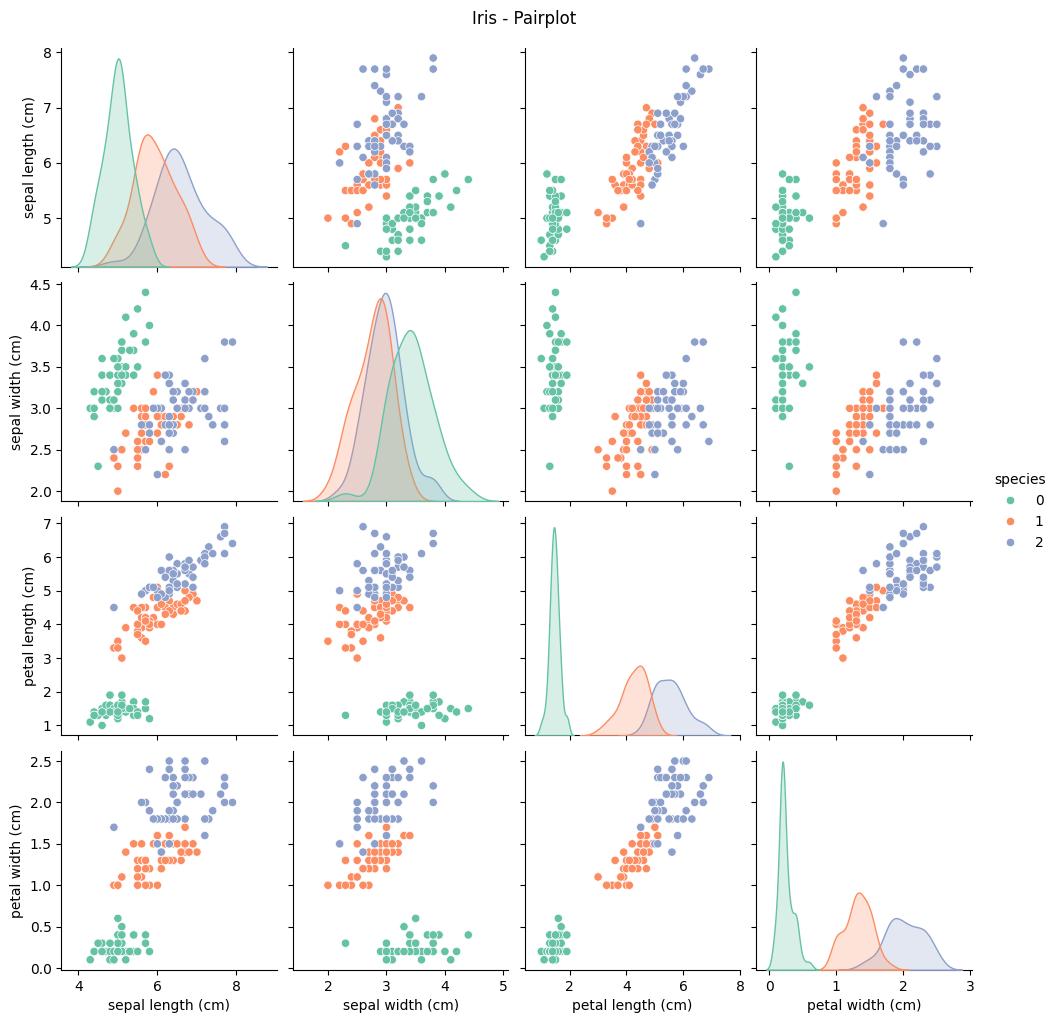


Model: KNN (k=5)
Accuracy: 93.33%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30


Model: Logistic Regression
Accuracy: 93.33%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Model: Decision Tree
Accuracy: 93.33%

Classification Report:
              precision    recall  f1-score   s

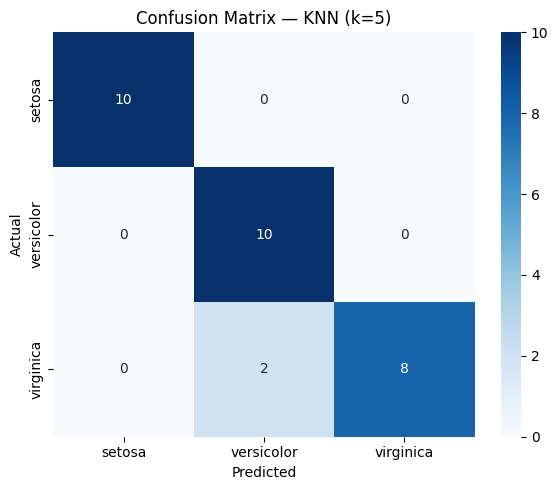


Best Model: KNN (k=5)
Best Accuracy: 93.33%

Sample Prediction: setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# Iris Flower Classification
# Using Scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix)

# ─────────────────────────────────────────
# 1. LOAD DATASET
# ─────────────────────────────────────────
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name='species')

print("Dataset Shape:", X.shape)
print("\nFirst 5 rows:")
print(X.head())
print("\nClass Distribution:")
print(y.value_counts())
# 0=setosa, 1=versicolor, 2=virginica

# ─────────────────────────────────────────
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ─────────────────────────────────────────
print("\nBasic Statistics:")
print(X.describe())

# Pairplot
sns.pairplot(pd.concat([X, y], axis=1), hue='species',
             palette='Set2')
plt.suptitle("Iris - Pairplot", y=1.02)
plt.savefig("pairplot.png", bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────
# 3. PREPROCESSING
# ─────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ─────────────────────────────────────────
# 4. TRAIN MULTIPLE MODELS
# ─────────────────────────────────────────
models = {
    "KNN (k=5)"           : KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression" : LogisticRegression(max_iter=200),
    "Decision Tree"       : DecisionTreeClassifier(random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"Accuracy: {acc*100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred,
          target_names=iris.target_names))

# ─────────────────────────────────────────
# 5. BEST MODEL — CONFUSION MATRIX
# ─────────────────────────────────────────
best_name = max(results, key=results.get)
best_model = models[best_name]
y_pred_best = best_model.predict(X_test_sc)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title(f"Confusion Matrix — {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

print(f"\nBest Model: {best_name}")
print(f"Best Accuracy: {results[best_name]*100:.2f}%")

# ─────────────────────────────────────────
# 6. PREDICT ON NEW SAMPLE
# ─────────────────────────────────────────
sample = np.array([[5.1, 3.5, 1.4, 0.2]])  # likely setosa
sample_sc = scaler.transform(sample)
pred = best_model.predict(sample_sc)
print(f"\nSample Prediction: {iris.target_names[pred[0]]}")